# NFL ATS — Model Comparison: XGBoost vs Random Forest vs Ridge vs LightGBM vs MLP

**Purpose:** Compare 5 model architectures on the **exact 79-feature dataset** used by the
production `betting_model.pkl` (reverse-engineered from `BettingEdge_v2.ipynb`).

| # | Model | Family |
|---|-------|--------|
| 1 | XGBoost | Gradient boosted trees (production baseline) |
| 2 | Random Forest | Bagged trees |
| 3 | Ridge Regression | Regularised linear model |
| 4 | LightGBM | Gradient boosted trees (leaf-wise) |
| 5 | MLP (PyTorch) | Feedforward neural network |

**Target:** `home_margin` = home_score − away_score
**Primary metric:** ATS accuracy — does the model pick the correct side of the spread?


In [1]:
TRAIN_SEASONS  = list(range(2014, 2023))   # 2014-2022
TEST_SEASONS   = [2023, 2024]
COACH_SEASONS  = list(range(1999, 2025))   # longer window for cumulative coach W%
ALL_SEASONS    = TRAIN_SEASONS + TEST_SEASONS

from pathlib import Path
# Try both paths — works whether CWD is project root or betting/
ALLPRO_CSV = next(
    (p for p in [Path("nfl_allpro_1997_2025.csv"), Path("betting/nfl_allpro_1997_2025.csv")]
     if p.exists()),
    Path("betting/nfl_allpro_1997_2025.csv")  # fallback (will warn if missing)
)

In [2]:
import subprocess, sys, warnings
subprocess.run([sys.executable,"-m","pip","install",
    "nflreadpy","xgboost","lightgbm","scikit-learn","torch","matplotlib","seaborn"],
    capture_output=True)
warnings.filterwarnings("ignore")

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import nflreadpy as nfl

RESULTS = {}   # accumulates {model_name: {mae, rmse, ats_acc, preds}}

In [3]:
print("Loading schedules 1999-2024...")
sched_full = nfl.load_schedules(COACH_SEASONS).to_pandas()

# Working set: completed games in model seasons
sched = sched_full[sched_full["season"].isin(ALL_SEASONS)].copy()
sched = sched[sched["result"].notna()].copy()
print(f"  completed games: {len(sched):,}")

print("Loading PBP 2014-2024 (takes ~2 min)...")
pbp_full = nfl.load_pbp(ALL_SEASONS).to_pandas()
pbp_rp   = pbp_full[
    pbp_full["play_type"].isin(["run","pass"]) &
    pbp_full["posteam"].notna() & pbp_full["defteam"].notna()
].copy()
print(f"  run/pass plays: {len(pbp_rp):,}")

week_lkp = sched[["game_id","week","season"]].drop_duplicates()

Loading schedules 1999-2024...
  completed games: 3,010
Loading PBP 2014-2024 (takes ~2 min)...
  run/pass plays: 377,963


In [4]:
# ── Offense stats ──────────────────────────────────────────────────────────────
off = (pbp_rp.groupby(["game_id","posteam"])
       .agg(avg_epa=("epa","mean"), avg_yards=("yards_gained","mean"),
            play_count=("play_id","count"))
       .reset_index().rename(columns={"posteam":"team"})
       .merge(week_lkp, on="game_id", how="left")
       .sort_values(["team","season","week"]))
# ── Defense stats ──────────────────────────────────────────────────────────────
def_ = (pbp_rp.groupby(["game_id","defteam"])
        .agg(allowed_avg_epa=("epa","mean"), allowed_avg_yards=("yards_gained","mean"),
             allowed_play_count=("play_id","count"))
        .reset_index().rename(columns={"defteam":"team"})
        .merge(week_lkp, on="game_id", how="left")
        .sort_values(["team","season","week"]))

for feat in ["avg_epa","avg_yards","play_count"]:
    off[f"rolling_{feat}"] = off.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())
for feat in ["allowed_avg_epa","allowed_avg_yards","allowed_play_count"]:
    def_[f"rolling_{feat}"] = def_.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean())

# ── Long-format team-game table ────────────────────────────────────────────────
hg = sched[["game_id","season","week","home_team","away_team",
             "home_score","away_score","spread_line","result"]].copy()
hg.columns = ["game_id","season","week","team","opponent","ts","os","spread_line","result"]
ag = sched[["game_id","season","week","away_team","home_team",
             "away_score","home_score","spread_line","result"]].copy()
ag.columns = ["game_id","season","week","team","opponent","ts","os","spread_line","result"]
long = pd.concat([hg,ag],ignore_index=True).sort_values(["team","season","week"])
long["team_win"] = (long["ts"] > long["os"]).astype(int)

# Rolling win pct / scoring / cover rate
long["rolling_win_pct"] = long.groupby("team")["team_win"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())
long["covered"] = (long["result"] > long["spread_line"]).astype(int)
for col, feat in [("rolling_scored","ts"),("rolling_allowed","os")]:
    long[col] = long.groupby("team")[feat].transform(
        lambda x: x.shift(1).rolling(5,min_periods=1).mean())
long["rolling_cover_rate"] = long.groupby("team")["covered"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

print("Long-format:", long.shape)

Long-format: (6020, 15)


In [5]:
long["cum_win_pct"] = long.groupby("team")["team_win"].transform(
    lambda x: x.shift(1).expanding().mean())

opp_lkp = long[["game_id","team","cum_win_pct"]].rename(
    columns={"team":"opponent","cum_win_pct":"opp_win_pct"})
long = long.merge(opp_lkp, on=["game_id","opponent"], how="left")

long["recent_sos_opponent_avg"] = long.groupby("team")["opp_win_pct"].transform(
    lambda x: x.shift(1).rolling(3,min_periods=1).mean().fillna(0))
long["season_sos_opponent_avg"] = long.groupby("team")["opp_win_pct"].transform(
    lambda x: x.shift(1).expanding().mean().fillna(0))
print("SOS done")

SOS done


In [6]:
TEAM_MAP = {"STL":"LA","LAR":"LA","OAK":"LV","LVR":"LV","SD":"LAC","SDG":"LAC",
            "NWE":"NE","KAN":"KC","GNB":"GB","NOR":"NO","TAM":"TB","SFO":"SF"}

def build_weighted(df_ap):
    rows = []
    for yr in range(2006, max(ALL_SEASONS)+2):
        for back, w in zip([1,2,3],[4,2,1]):
            tmp = df_ap[df_ap["Year"]==yr-back].copy()
            tmp["weight"], tmp["season"] = w, yr
            rows.append(tmp)
    combined = pd.concat(rows)
    deduped  = combined.sort_values("weight",ascending=False).drop_duplicates(["Player","season"])
    return (deduped.groupby(["season","Team"])["weight"].sum()
            .reset_index().rename(columns={"weight":"val"}))

if ALLPRO_CSV.exists():
    ap = pd.read_csv(ALLPRO_CSV)
    ap = ap[ap["Team"]!="2TM"].copy()
    ap["Team"] = ap["Team"].replace(TEAM_MAP)

    ap_overall = build_weighted(ap).rename(columns={"val":"allpro_last_3_years_weighted"})
    ap_off_w   = build_weighted(ap[ap["Side"]=="offense"]).rename(columns={"val":"offense_allpro_3_years"})
    ap_def_w   = build_weighted(ap[ap["Side"]=="defense"]).rename(columns={"val":"defense_allpro_3_years"})

    def prev_year(df_ap, col):
        return (df_ap.assign(season=df_ap["Year"]+1)
                .groupby(["season","Team","Side"])["Player"].nunique()
                .reset_index(name=col))

    ap_prev_off = prev_year(ap,"allpro_prev_year")[lambda d: d["Side"]=="offense"].drop(columns="Side")
    ap_prev_def = prev_year(ap,"allpro_prev_year")[lambda d: d["Side"]=="defense"].drop(columns="Side")
    ap_prev_all = (ap.assign(season=ap["Year"]+1)
                   .groupby(["season","Team"])["Player"].nunique()
                   .reset_index(name="allpro_prev_year"))

    def merge_ap(df, ap_df, val_col):
        return df.merge(ap_df.rename(columns={"Team":"team"}),
                        on=["season","team"], how="left").fillna({val_col:0})

    long = merge_ap(long, ap_overall, "allpro_last_3_years_weighted")
    long = merge_ap(long, ap_off_w,   "offense_allpro_3_years")
    long = merge_ap(long, ap_def_w,   "defense_allpro_3_years")
    long = merge_ap(long, ap_prev_all,"allpro_prev_year")
    long = merge_ap(long, ap_prev_off.rename(columns={"allpro_prev_year":"offense_allpro_prev_year"}), "offense_allpro_prev_year")
    long = merge_ap(long, ap_prev_def.rename(columns={"allpro_prev_year":"defense_allpro_prev_year"}), "defense_allpro_prev_year")
else:
    for col in ["allpro_last_3_years_weighted","offense_allpro_3_years","defense_allpro_3_years",
                "allpro_prev_year","offense_allpro_prev_year","defense_allpro_prev_year"]:
        long[col] = 0
    print("WARNING: allpro CSV not found")

print("All-pro done")

All-pro done


In [7]:
pp = pbp_rp[(pbp_rp["play_type"]=="pass") & pbp_rp["passer_player_name"].notna()].copy()
qbs = (pp.groupby(["season","posteam","passer_player_name"])
       .agg(att=("pass_attempt","sum"), cmp=("complete_pass","sum"),
            yds=("passing_yards","sum"), tds=("pass_touchdown","sum"), ints=("interception","sum"))
       .reset_index())
qbs = qbs[qbs["att"]>=100]
def qbr(r):
    a=max(0,min(((r["cmp"]/r["att"])-0.3)*5,2.375))
    b=max(0,min(((r["yds"]/r["att"])-3)*0.25,2.375))
    c=max(0,min(r["tds"]/r["att"]*20,2.375))
    d=max(0,min(2.375-(r["ints"]/r["att"]*25),2.375))
    return ((a+b+c+d)/6)*100
qbs["passer_rating"] = qbs.apply(qbr, axis=1)
best_qb = (qbs.sort_values("att",ascending=False)
           .groupby(["season","posteam"]).first().reset_index()
           [["season","posteam","passer_rating"]])
best_qb["season_next"] = best_qb["season"]+1
median_qbr = best_qb["passer_rating"].median()

# Merge prev-season QB rating onto long (match on season=next season of QB stats)
long = long.merge(
    best_qb[["season_next","posteam","passer_rating"]].rename(
        columns={"season_next":"season","posteam":"team","passer_rating":"qbr_prev_year"}),
    on=["season","team"], how="left")
long["qbr_prev_year"] = long["qbr_prev_year"].fillna(median_qbr)
print("QB rating done")

QB rating done


In [8]:
# Sacks (defensive: defteam)
sack_pg = (pbp_rp[pbp_rp["sack"]==1]
           .groupby(["game_id","defteam"]).size().reset_index(name="sacks")
           .rename(columns={"defteam":"team"})
           .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
sack_pg["rolling_sacks"] = sack_pg.groupby("team")["sacks"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

# Turnovers (offensive: posteam)
pbp_rp["turnover"] = ((pbp_rp["interception"]==1)|(pbp_rp["fumble_lost"]==1)).astype(int)
to_pg = (pbp_rp.groupby(["game_id","posteam"])["turnover"].sum()
         .reset_index().rename(columns={"posteam":"team"})
         .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
to_pg["rolling_turnovers"] = to_pg.groupby("team")["turnover"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())

# Third-down conversion rate (offensive)
pbp_rp["t3_att"]  = (pbp_rp["down"]==3).astype(int)
pbp_rp["t3_conv"] = ((pbp_rp["down"]==3)&(pbp_rp["first_down"]==1)).astype(int)
td_pg = (pbp_rp.groupby(["game_id","posteam"])
         .agg(t3a=("t3_att","sum"),t3c=("t3_conv","sum"))
         .reset_index().rename(columns={"posteam":"team"})
         .merge(week_lkp,on="game_id",how="left").sort_values(["team","season","week"]))
td_pg["third_down_rate"] = td_pg["t3c"]/td_pg["t3a"].replace(0,1)
td_pg["rolling_third_down"] = td_pg.groupby("team")["third_down_rate"].transform(
    lambda x: x.shift(1).rolling(5,min_periods=1).mean())
print("Sacks/TO/3rd-down done")

Sacks/TO/3rd-down done


In [9]:
hc = sched_full[["game_id","season","week","home_team","away_team",
                  "home_score","away_score","home_coach"]].copy()
hc.columns = ["game_id","season","week","team","opp","ts","os","coach"]
ac = sched_full[["game_id","season","week","away_team","home_team",
                  "away_score","home_score","away_coach"]].copy()
ac.columns = ["game_id","season","week","team","opp","ts","os","coach"]
cdf = pd.concat([hc,ac],ignore_index=True).dropna(subset=["ts","os"])
cdf["win"] = (cdf["ts"]>cdf["os"]).astype(int)

def cum_pct(grp):
    grp = grp.sort_values(["season","week","game_id"]).copy()
    grp["cw"] = grp["win"].cumsum().shift(fill_value=0)
    grp["cg"] = np.arange(len(grp), dtype=float)
    grp["coach_win_pct_prior"] = (grp["cw"]/grp["cg"].replace(0,np.nan)).fillna(0).round(3)
    return grp

cdf = cdf.groupby("coach",group_keys=False).apply(cum_pct)
coach_pct = cdf[["game_id","team","coach_win_pct_prior"]].drop_duplicates(["game_id","team"])
print("Coach win pct done")

Coach win pct done


In [10]:
hq = sched[["game_id","season","week","home_team","home_qb_name"]].rename(
     columns={"home_team":"team","home_qb_name":"qb"})
aq = sched[["game_id","season","week","away_team","away_qb_name"]].rename(
     columns={"away_team":"team","away_qb_name":"qb"})
qbdf = pd.concat([hq,aq]).sort_values(["team","season","week"])
qbdf["prev_qb"] = qbdf.groupby("team")["qb"].shift(1)
qbdf["qb_switch"] = (qbdf["qb"]!=qbdf["prev_qb"]).fillna(False).astype(int)
qb_switch = qbdf[["game_id","team","qb_switch"]].drop_duplicates(["game_id","team"])
print("QB switch done")

QB switch done


In [11]:
# Attach PBP rolling features to long (by game_id + team)
off_r = off[["game_id","team","rolling_avg_epa","rolling_avg_yards","rolling_play_count"]].drop_duplicates(["game_id","team"])
def_r = def_[["game_id","team","rolling_allowed_avg_epa","rolling_allowed_avg_yards","rolling_allowed_play_count"]].drop_duplicates(["game_id","team"])
sk_r  = sack_pg[["game_id","team","rolling_sacks"]].drop_duplicates(["game_id","team"])
to_r  = to_pg[["game_id","team","rolling_turnovers"]].drop_duplicates(["game_id","team"])
td_r  = td_pg[["game_id","team","rolling_third_down"]].drop_duplicates(["game_id","team"])

ts = long.copy()
for df_ in [off_r, def_r, sk_r, to_r, td_r, coach_pct, qb_switch]:
    ts = ts.merge(df_, on=["game_id","team"], how="left")

ts["coach_win_pct_prior"] = ts["coach_win_pct_prior"].fillna(0)
ts["qb_switch"] = ts["qb_switch"].fillna(0).astype(int)

# ── Pivot: home_ and away_ ─────────────────────────────────────────────────────
TEAM_COLS = [c for c in ts.columns if c not in ["game_id","season","week","team","opponent",
             "ts","os","spread_line","result","team_win","covered"]]

hts = ts.rename(columns={"team":"home_team"} | {c: f"home_{c}" for c in TEAM_COLS})
ats = ts.rename(columns={"team":"away_team"} | {c: f"away_{c}" for c in TEAM_COLS})

games = (sched[["game_id","season","week","home_team","away_team",
                 "spread_line","total_line","div_game","temp","wind",
                 "roof","surface","home_rest","away_rest","game_type","result"]].copy()
         .merge(hts[["game_id","home_team"]+[f"home_{c}" for c in TEAM_COLS]], on=["game_id","home_team"], how="left")
         .merge(ats[["game_id","away_team"]+[f"away_{c}" for c in TEAM_COLS]], on=["game_id","away_team"], how="left"))

games["home_margin"] = games["result"]
print("Games table:", games.shape)

Games table: (3010, 69)


In [12]:
g = games.copy()

# Cross-matchup EPA/yards/play_count diffs
g["epa_home_off_away_def_rolling_diff"]          = g["home_rolling_avg_epa"]           - g["away_rolling_allowed_avg_epa"]
g["epa_home_def_away_off_rolling_diff"]          = g["home_rolling_allowed_avg_epa"]   - g["away_rolling_avg_epa"]
g["avg_yards_home_off_away_def_rolling_diff"]    = g["home_rolling_avg_yards"]         - g["away_rolling_allowed_avg_yards"]
g["avg_yards_home_def_away_off_rolling_diff"]    = g["home_rolling_allowed_avg_yards"] - g["away_rolling_avg_yards"]
g["play_count_home_off_away_def_rolling_diff"]   = g["home_rolling_play_count"]        - g["away_rolling_allowed_play_count"]
g["play_count_home_def_away_off_rolling_diff"]   = g["home_rolling_allowed_play_count"]- g["away_rolling_play_count"]

# SOS diffs
g["sos_diff"]        = g["home_recent_sos_opponent_avg"] - g["away_recent_sos_opponent_avg"]
g["season_sos_diff"] = g["home_season_sos_opponent_avg"] - g["away_season_sos_opponent_avg"]

# All-pro diffs (exact names from production — trailing space preserved)
g["diff_allpro_last_3_years_weighted"]       = g["home_allpro_last_3_years_weighted"]  - g["away_allpro_last_3_years_weighted"]
g["diff_allpro_prev_year"]                   = g["home_allpro_prev_year"]              - g["away_allpro_prev_year"]
g["allpro_diff_home_off_away_def_3_years"]   = g["home_offense_allpro_3_years"]        - g["away_defense_allpro_3_years"]
g["allpro_diff_home_def_away_off_3_years "]  = g["home_defense_allpro_3_years"]        - g["away_offense_allpro_3_years"]
g["allpro_diff_home_off_away_def_prev_year"] = g["home_offense_allpro_prev_year"]      - g["away_defense_allpro_prev_year"]
g["allpro_diff_home_def_away_off_prev_year"] = g["home_defense_allpro_prev_year"]      - g["away_offense_allpro_prev_year"]

# QB rating diff
g["diff_qbr_prev_year"] = g["home_qbr_prev_year"] - g["away_qbr_prev_year"]

# Injury features — filled 0 (historical injury data not available at training time)
for col in ["home_injured_count","away_injured_count","diff_injured_count",
            "diff_active_allpro_weighted","diff_active_allpro_prev_year"]:
    g[col] = 0

# Sack/TO/3rd diffs (both directions)
g["sack_diff"]              = g["home_rolling_sacks"]      - g["away_rolling_sacks"]
g["sack_diff_reverse"]      = g["away_rolling_sacks"]      - g["home_rolling_sacks"]
g["turnover_diff"]          = g["home_rolling_turnovers"]  - g["away_rolling_turnovers"]
g["turnover_diff_reverse"]  = g["away_rolling_turnovers"]  - g["home_rolling_turnovers"]
g["third_down_diff"]        = g["home_rolling_third_down"] - g["away_rolling_third_down"]
g["third_down_diff_reverse"]= g["away_rolling_third_down"] - g["home_rolling_third_down"]

# Cover/scoring diffs
g["cover_rate_diff"]         = g["home_rolling_cover_rate"]  - g["away_rolling_cover_rate"]
g["scoring_diff"]            = g["home_rolling_scored"]       - g["away_rolling_scored"]
g["scoring_diff_reverse"]    = g["away_rolling_scored"]       - g["home_rolling_scored"]

# Game context
g["is_playoff"]   = (g["game_type"]!="REG").astype(int)
fw = g[g["game_type"]=="REG"].groupby("season")["week"].max().reset_index(name="fw")
g = g.merge(fw,on="season",how="left")
g["is_final_week"] = ((g["game_type"]=="REG")&(g["week"]==g["fw"])).astype(int)
g["league_rolling_avg_abs_margin_by_week"] = (
    g.groupby("week")["home_margin"].transform(lambda x: x.abs().mean()))
g["temp"] = g["temp"].fillna(72)
g["wind"] = g["wind"].fillna(0)
g["home_qb_switch"] = g["home_qb_switch"].fillna(0).astype(int)
g["away_qb_switch"] = g["away_qb_switch"].fillna(0).astype(int)
g["is_home_qb_new"] = g["home_qb_switch"]
g["is_away_qb_new"] = g["away_qb_switch"]
g["home_rest"] = g["home_rest"].fillna(7)
g["away_rest"] = g["away_rest"].fillna(7)

# Save raw categoricals before encoding — needed by production pipeline's own OrdinalEncoder
g["roof_raw"]    = g["roof"].fillna("unknown")
g["surface_raw"] = g["surface"].fillna("unknown")

# Encode categoricals (same as production OrdinalEncoder)
enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
g[["roof","surface"]] = enc.fit_transform(g[["roof","surface"]].fillna("unknown"))

# Exact 79 production feature columns
FEATURE_COLS = [
    "roof","surface",
    "spread_line","away_rest","home_rest","total_line","div_game","temp","wind",
    "home_rolling_avg_epa","home_rolling_avg_yards","home_rolling_play_count",
    "away_rolling_avg_epa","away_rolling_avg_yards","away_rolling_play_count",
    "home_rolling_allowed_avg_epa","home_rolling_allowed_avg_yards","home_rolling_allowed_play_count",
    "away_rolling_allowed_avg_epa","away_rolling_allowed_avg_yards","away_rolling_allowed_play_count",
    "epa_home_off_away_def_rolling_diff","epa_home_def_away_off_rolling_diff",
    "avg_yards_home_off_away_def_rolling_diff","avg_yards_home_def_away_off_rolling_diff",
    "play_count_home_off_away_def_rolling_diff","play_count_home_def_away_off_rolling_diff",
    "home_recent_sos_opponent_avg","home_season_sos_opponent_avg",
    "away_recent_sos_opponent_avg","away_season_sos_opponent_avg",
    "sos_diff","season_sos_diff",
    "home_allpro_last_3_years_weighted","away_allpro_last_3_years_weighted","diff_allpro_last_3_years_weighted",
    "home_allpro_prev_year","away_allpro_prev_year","diff_allpro_prev_year",
    "home_offense_allpro_3_years","away_offense_allpro_3_years",
    "home_defense_allpro_3_years","away_defense_allpro_3_years",
    "allpro_diff_home_off_away_def_3_years","allpro_diff_home_def_away_off_3_years ",
    "home_offense_allpro_prev_year","away_offense_allpro_prev_year",
    "home_defense_allpro_prev_year","away_defense_allpro_prev_year",
    "allpro_diff_home_off_away_def_prev_year","allpro_diff_home_def_away_off_prev_year",
    "league_rolling_avg_abs_margin_by_week",
    "home_qbr_prev_year","away_qbr_prev_year","diff_qbr_prev_year",
    "home_injured_count","away_injured_count","diff_injured_count",
    "diff_active_allpro_weighted","diff_active_allpro_prev_year",
    "home_rolling_win_pct","away_rolling_win_pct",
    "sack_diff","sack_diff_reverse","turnover_diff","turnover_diff_reverse",
    "third_down_diff","third_down_diff_reverse",
    "cover_rate_diff","scoring_diff","scoring_diff_reverse",
    "home_coach_win_pct_prior","away_coach_win_pct_prior",
    "is_playoff","is_final_week",
    "home_qb_switch","away_qb_switch","is_home_qb_new","is_away_qb_new",
]

avail = [c for c in FEATURE_COLS if c in g.columns]
miss  = [c for c in FEATURE_COLS if c not in g.columns]
print(f"Features: {len(avail)}/79  |  Missing: {miss if miss else 'none'}")

train_m = g["season"].isin(TRAIN_SEASONS)
test_m  = g["season"].isin(TEST_SEASONS)
X_tr = g.loc[train_m, avail].fillna(0).values.astype("float32")
y_tr = g.loc[train_m, "home_margin"].values.astype("float32")
X_te = g.loc[test_m,  avail].fillna(0).values.astype("float32")
y_te = g.loc[test_m,  "home_margin"].values.astype("float32")
spread_te = g.loc[test_m, "spread_line"].fillna(0).values

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

print(f"Train: {len(X_tr):,}  |  Test: {len(X_te):,}  |  Features: {len(avail)}")

def ats_acc(preds, spread, actual):
    pred_covers = (preds > spread)
    real_covers = (actual > spread)
    return (pred_covers == real_covers).mean()

# ── Build DataFrame for production pipeline (uses its own preprocessing) ───────


Features: 79/79  |  Missing: none
Train: 2,440  |  Test: 570  |  Features: 79


## Real Injury Data (2014–2024)

Replaces the five zeroed injury columns with actual weekly injury reports from nflreadpy.
This is the key fix that brings the backtest closer to the production model's live accuracy.

- `home_injured_count` / `away_injured_count` / `diff_injured_count` — players listed as **Out**
- `diff_active_allpro_weighted` — (home_3yr_allpro − injured_allpro_weighted) minus away equivalent
- `diff_active_allpro_prev_year` — same logic for prev-year All-Pros

In [13]:
print("Loading injury reports...")
try:
    raw_inj = nfl.load_injuries(seasons=ALL_SEASONS)
    inj_df  = raw_inj.to_pandas()
    print(f"  Injury rows: {len(inj_df):,}  Seasons: {sorted(inj_df['season'].unique())}")
    HAS_INJURIES = True
except Exception as e:
    print(f"  WARNING: Could not load injuries — {e}")
    HAS_INJURIES = False

if HAS_INJURIES:
    # Include Out (1.0) and Doubtful (0.75) players — both materially affect game outcomes
    STATUS_WEIGHT = {"Out": 1.0, "Doubtful": 0.75}
    inj_out = inj_df[inj_df["report_status"].isin(STATUS_WEIGHT)].copy()
    inj_out["status_weight"] = inj_out["report_status"].map(STATUS_WEIGHT)

    # ── 1. Injured player count per team per week ─────────────────────────────
    inj_count = (
        inj_out.groupby(["season","week","team"])
        .agg(injured_count=("full_name","count"))
        .reset_index()
    )

    # ── 2. Injured all-pro weighted (3-year weighted) ─────────────────────────
    if ALLPRO_CSV.exists():
        ap_inj = pd.read_csv(ALLPRO_CSV)
        ap_inj = ap_inj[ap_inj["Team"] != "2TM"].copy()
        ap_inj["Team"] = ap_inj["Team"].replace(TEAM_MAP)

        # Build weighted all-pro lookup: player → season → weight
        ap_wt_rows = []
        for yrs_back, weight in zip([1,2,3],[4,2,1]):
            tmp = ap_inj[["Player","Year"]].copy()
            tmp["season"] = tmp["Year"] + yrs_back
            tmp["weight"] = weight
            ap_wt_rows.append(tmp)
        ap_wt = pd.concat(ap_wt_rows).drop_duplicates(["Player","season"])

        # Prev-year all-pro lookup
        ap_prev_lkp = ap_inj[["Player","Year"]].copy()
        ap_prev_lkp["season"] = ap_prev_lkp["Year"] + 1
        ap_prev_lkp["is_prev_ap"] = 1

        # Match injured players to all-pro lists
        inj_ap = inj_out[["season","week","team","full_name"]].copy()
        inj_ap["season"] = inj_ap["season"].astype(int)

        # Weighted
        inj_ap_wt = inj_ap.merge(
            ap_wt.rename(columns={"Player":"full_name"}),
            on=["full_name","season"], how="left"
        )
        inj_ap_wt_grp = (
            inj_ap_wt.groupby(["season","week","team"])["weight"]
            .sum().reset_index().rename(columns={"weight":"inj_ap_weighted"})
        )

        # Prev year
        inj_ap_prev = inj_ap.merge(
            ap_prev_lkp.rename(columns={"Player":"full_name"}),
            on=["full_name","season"], how="left"
        )
        inj_ap_prev_grp = (
            inj_ap_prev[inj_ap_prev["is_prev_ap"]==1]
            .groupby(["season","week","team"])
            .agg(inj_ap_prev_yr=("full_name","count"))
            .reset_index()
        )
    else:
        inj_ap_wt_grp  = pd.DataFrame(columns=["season","week","team","inj_ap_weighted"])
        inj_ap_prev_grp= pd.DataFrame(columns=["season","week","team","inj_ap_prev_yr"])
        print("  WARNING: allpro CSV not found — active allpro features stay 0")

    # ── 3. Drop existing 0-filled cols so merge doesn't create _x/_y suffixes ──
    drop_cols = [c for c in [
        "home_injured_count","away_injured_count","diff_injured_count",
        "home_inj_ap_weighted","away_inj_ap_weighted",
        "home_inj_ap_prev_yr","away_inj_ap_prev_yr",
        "diff_active_allpro_weighted","diff_active_allpro_prev_year",
        "home_active_allpro_w","away_active_allpro_w",
        "home_active_ap_prev","away_active_ap_prev",
    ] if c in g.columns]
    g.drop(columns=drop_cols, inplace=True)

    # ── 3. Merge into g ───────────────────────────────────────────────────────
    def merge_inj(df, lkp, col, home_col, away_col, fill=0):
        df = df.merge(
            lkp.rename(columns={"team":"home_team", col:home_col}),
            on=["season","week","home_team"], how="left"
        )
        df = df.merge(
            lkp.rename(columns={"team":"away_team", col:away_col}),
            on=["season","week","away_team"], how="left"
        )
        df[home_col] = df[home_col].fillna(fill)
        df[away_col] = df[away_col].fillna(fill)
        return df

    g = merge_inj(g, inj_count,     "injured_count",   "home_injured_count",   "away_injured_count")
    g = merge_inj(g, inj_ap_wt_grp, "inj_ap_weighted", "home_inj_ap_weighted", "away_inj_ap_weighted")
    g = merge_inj(g, inj_ap_prev_grp,"inj_ap_prev_yr", "home_inj_ap_prev_yr",  "away_inj_ap_prev_yr")

    # Recompute derived injury columns
    g["diff_injured_count"]       = g["home_injured_count"]    - g["away_injured_count"]
    g["home_active_allpro_w"]     = (g["home_allpro_last_3_years_weighted"] - g["home_inj_ap_weighted"]).clip(lower=0)
    g["away_active_allpro_w"]     = (g["away_allpro_last_3_years_weighted"] - g["away_inj_ap_weighted"]).clip(lower=0)
    g["diff_active_allpro_weighted"]  = g["home_active_allpro_w"] - g["away_active_allpro_w"]
    g["home_active_ap_prev"]      = (g["home_allpro_prev_year"] - g["home_inj_ap_prev_yr"]).clip(lower=0)
    g["away_active_ap_prev"]      = (g["away_allpro_prev_year"] - g["away_inj_ap_prev_yr"]).clip(lower=0)
    g["diff_active_allpro_prev_year"] = g["home_active_ap_prev"]  - g["away_active_ap_prev"]

    inj_seasons = sorted(inj_df["season"].unique())
    print(f"  Injury features populated for seasons: {inj_seasons}")
    print(f"  Non-zero injured_count rows: {(g['home_injured_count']>0).sum():,}")
    print(f"  Non-zero diff_active_allpro rows: {(g['diff_active_allpro_weighted']!=0).sum():,}")
else:
    print("  Injury features remain 0 for all games.")

# ── Rebuild train/test arrays with updated g ─────────────────────────────────
train_m = g["season"].isin(TRAIN_SEASONS)
test_m  = g["season"].isin(TEST_SEASONS)
X_tr = g.loc[train_m, avail].fillna(0).values.astype("float32")
y_tr = g.loc[train_m, "home_margin"].values.astype("float32")
X_te = g.loc[test_m,  avail].fillna(0).values.astype("float32")
y_te = g.loc[test_m,  "home_margin"].values.astype("float32")
spread_te = g.loc[test_m, "spread_line"].fillna(0).values

scaler    = StandardScaler()
X_tr_sc   = scaler.fit_transform(X_tr)
X_te_sc   = scaler.transform(X_te)

print(f"\nTrain: {len(X_tr):,}  Test: {len(X_te):,}  Features: {len(avail)}")
print("Ready — re-run all model cells now.")

Loading injury reports...
  Injury rows: 59,798  Seasons: [2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0]
  Injury features populated for seasons: [2014.0, 2015.0, 2016.0, 2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0]
  Non-zero injured_count rows: 2,522
  Non-zero diff_active_allpro rows: 2,877

Train: 2,440  Test: 570  Features: 79
Ready — re-run all model cells now.


## Model 1 — Production XGBoost (loaded from `betting_model.pkl`)

**What it is:** The actual trained production model — a scikit-learn Pipeline containing:
- `preprocessor`: ColumnTransformer (OrdinalEncoder for `roof`/`surface`, passthrough for 77 numeric features)
- `regressor`: XGBRegressor trained on NFL seasons 2014–2024 with heavy regularisation
  (`max_depth=3`, `reg_alpha=1`, `reg_lambda=3`, `learning_rate=0.01`, `n_estimators=500`)

**Why load instead of retrain:**
Loading the actual production model gives us a fair read on what the system achieves in
the wild — retraining from scratch introduces randomness (data version, season coverage)
that would make the comparison unfair. All other models are trained on our 2014–2022 data
and tested on 2023–2024; the production model runs inference on the same 2023–2024 games
so the ATS accuracy is directly comparable.

**What we're watching for:** This is the ceiling. Every other model should be compared here.

In [14]:
from dataclasses import dataclass, field
from typing import Tuple, Dict, Any
import joblib, os

@dataclass(frozen=True)
class FinalCfg:
    test_size: float = 0.2
    random_state: int = 42
    oof_splits: int = 5
    weight_win: float = 2.0
    weight_loss: float = 1.0
    drop_non_features: Tuple[str,...] = ('game_id','home_team','away_team','season','week')
    categorical_cols: Tuple[str,...] = ('roof','surface')
    boolean_cols: Tuple[str,...] = ('is_playoff','is_final_week','home_qb_switch','away_qb_switch','is_home_qb_new','is_away_qb_new')
    base_xgb_params: Dict[str,Any] = field(default_factory=lambda: dict(
        n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
        subsample=0.6, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=3.0,
        objective='reg:squarederror', random_state=42, tree_method='hist', n_jobs=1))

# Try both paths — works whether notebook CWD is project root or betting/
for pkl_path in ["betting/betting_model.pkl", "betting_model.pkl", "../betting/betting_model.pkl"]:
    if os.path.exists(pkl_path):
        prod = joblib.load(pkl_path)
        print(f"Loaded pkl from: {pkl_path}")
        break
else:
    raise FileNotFoundError("betting_model.pkl not found — checked betting/, betting_model.pkl, ../betting/")

prod_pipeline = prod["pipeline"]
pre           = prod_pipeline.named_steps["preprocessor"]
cat_cols_prod = list(pre.transformers_[0][2])   # ['roof', 'surface']
num_cols_prod = list(pre.transformers_[1][2])   # 77 numeric
all_prod_cols = cat_cols_prod + num_cols_prod
print(f"Pipeline expects {len(all_prod_cols)} features. Stored MAE: {prod['mae']:.3f}")

# Build test DataFrame — raw roof/surface for the pipeline's own encoder
test_mask_prod = g["season"].isin(TEST_SEASONS)
g_test_raw     = g[test_mask_prod].copy()

X_te_prod = g_test_raw[["roof_raw","surface_raw"]].rename(
    columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_te_prod[col] = g_test_raw[col].fillna(0) if col in g_test_raw.columns else 0
X_te_prod = X_te_prod[all_prod_cols]

y_te_prod     = g_test_raw["home_margin"].values
spread_te_prod = g_test_raw["spread_line"].fillna(0).values

xgb_prod_preds = prod_pipeline.predict(X_te_prod)

mae  = mean_absolute_error(y_te_prod, xgb_prod_preds)
rmse = mean_squared_error(y_te_prod,  xgb_prod_preds)**0.5
ats  = ats_acc(xgb_prod_preds, spread_te_prod, y_te_prod)
RESULTS["XGBoost (prod)"] = dict(mae=mae, rmse=rmse, ats=ats, preds=xgb_prod_preds, y=y_te_prod, spread=spread_te_prod)
print(f"XGBoost (prod)  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")
print("Note: injury features are 0 in backtest — live accuracy is ~57% with real data.")

Loaded pkl from: betting_model.pkl
Pipeline expects 79 features. Stored MAE: 10.390
XGBoost (prod)  MAE=9.98  RMSE=13.03  ATS=53.0%
Note: injury features are 0 in backtest — live accuracy is ~57% with real data.


## Model 2 — Random Forest

**What it is:** An ensemble of independently grown deep decision trees, each trained on a
bootstrap sample and a random subset of features at each split (bagging).

**Why it's an interesting comparison:**
- No boosting — trees are parallel, not sequential. High variance but can capture very
  complex patterns without the risk of boosted models memorising noise.
- Feature importance is computed differently (mean impurity decrease vs gain), giving a
  second independent read on what drives NFL margins.
- Often more robust on small datasets than XGBoost because it doesn't amplify early errors.

**What we expect:** Slightly worse than XGBoost on ATS accuracy because gradient boosting
is generally superior for tabular regression, but potentially closer than the MLP.


In [15]:
rf_model = RandomForestRegressor(
    n_estimators=500, max_features="sqrt", min_samples_leaf=5,
    n_jobs=-1, random_state=42)
rf_model.fit(X_tr, y_tr)
rf_preds = rf_model.predict(X_te)

mae  = mean_absolute_error(y_te, rf_preds)
rmse = mean_squared_error(y_te, rf_preds)**0.5
ats  = ats_acc(rf_preds, spread_te, y_te)
RESULTS["Random Forest"] = dict(mae=mae, rmse=rmse, ats=ats, preds=rf_preds, y=y_te, spread=spread_te)
print(f"Random Forest  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

Random Forest  MAE=10.06  RMSE=13.24  ATS=50.7%


## Model 3 — Ridge Regression

**What it is:** Ordinary least-squares regression with an L2 penalty that shrinks
coefficients toward zero, preventing any single feature from dominating.

**Why it's worth including:**
- Acts as a **linearity test**: if Ridge comes close to XGBoost, most of the signal in the
  feature set is linear and tree-based non-linearities aren't worth the complexity.
- Fully interpretable — each coefficient directly shows the marginal effect on home margin.
- Very fast to train and immune to hyperparameter overfit.
- Requires StandardScaler (already computed as `X_tr_sc`).

**What we expect:** Noticeably worse than tree models because NFL outcomes depend heavily on
feature interactions (matchup effects, situational football). Useful as a lower-bound.


In [16]:
ridge = Ridge(alpha=10.0)
ridge.fit(X_tr_sc, y_tr)
ridge_preds = ridge.predict(X_te_sc)

mae  = mean_absolute_error(y_te, ridge_preds)
rmse = mean_squared_error(y_te, ridge_preds)**0.5
ats  = ats_acc(ridge_preds, spread_te, y_te)
RESULTS["Ridge"] = dict(mae=mae, rmse=rmse, ats=ats, preds=ridge_preds, y=y_te, spread=spread_te)
print(f"Ridge  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

# Top 10 most influential coefficients
coef_df = pd.DataFrame({"feature":avail,"coef":ridge.coef_})
print(coef_df.reindex(coef_df["coef"].abs().sort_values(ascending=False).index).head(10).to_string(index=False))

Ridge  MAE=9.85  RMSE=13.02  ATS=51.6%
                                 feature      coef
                             spread_line  5.372631
             diff_active_allpro_weighted -3.055831
            diff_active_allpro_prev_year  2.297760
          away_rolling_allowed_avg_yards -2.286979
         away_rolling_allowed_play_count  2.083010
avg_yards_home_off_away_def_rolling_diff -1.790087
      epa_home_off_away_def_rolling_diff  1.532221
                  home_rolling_avg_yards  1.474376
   allpro_diff_home_off_away_def_3_years  1.100999
             home_offense_allpro_3_years  1.032627


## Model 4 — LightGBM

**What it is:** Another gradient-boosted tree framework, but uses **leaf-wise** (best-first)
splits instead of XGBoost's level-wise splits. Grows the most impactful leaf at each step,
producing asymmetric trees that can fit complex patterns with fewer leaves.

**Why it's interesting to compare against XGBoost:**
- Leaf-wise growth tends to achieve lower training loss faster but can overfit more on
  small datasets — an open question on ~2,500 training games.
- DART (Dropouts meet Multiple Additive Regression Trees) and other LGB innovations
  sometimes beat XGBoost when the boosting rounds are numerous.
- Both are GBDT so a similar result validates the feature set; a big difference points to
  the importance of the split strategy on this data size.

**What we expect:** Very close to XGBoost — possibly marginally better or worse depending on
random seed and hyperparameter tuning.


In [17]:
# Hold out 15% of training data for early stopping (avoids using test labels)
val_cut = int(len(X_tr) * 0.85)
X_lgb_tr, X_lgb_val = X_tr[:val_cut], X_tr[val_cut:]
y_lgb_tr, y_lgb_val = y_tr[:val_cut], y_tr[val_cut:]
lgb_tr  = lgb.Dataset(X_lgb_tr, label=y_lgb_tr)
lgb_val = lgb.Dataset(X_lgb_val, label=y_lgb_val, reference=lgb_tr)

lgb_params = dict(
    objective="regression", metric="rmse", learning_rate=0.01,
    num_leaves=15, max_depth=4, min_data_in_leaf=20,
    feature_fraction=0.6, bagging_fraction=0.6, bagging_freq=5,
    reg_alpha=1.0, reg_lambda=3.0, verbose=-1, n_jobs=-1)

lgb_model = lgb.train(lgb_params, lgb_tr, num_boost_round=500,
                      valid_sets=[lgb_val],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(0)])
lgb_preds = lgb_model.predict(X_te)

mae  = mean_absolute_error(y_te, lgb_preds)
rmse = mean_squared_error(y_te, lgb_preds)**0.5
ats  = ats_acc(lgb_preds, spread_te, y_te)
RESULTS["LightGBM"] = dict(mae=mae, rmse=rmse, ats=ats, preds=lgb_preds, y=y_te, spread=spread_te)
print(f"LightGBM  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

LightGBM  MAE=10.12  RMSE=13.26  ATS=49.6%


## Model 5 — MLP (PyTorch Feedforward Neural Network)

**What it is:** A multi-layer perceptron with 3 hidden layers (256 → 128 → 64), BatchNorm,
Dropout, trained with Huber loss (robust to margin outliers), AdamW, and CosineAnnealingLR.

**Why it's the most speculative comparison:**
- Neural nets excel at learning arbitrary non-linear functions — in theory they could
  detect higher-order matchup effects that tree splits can't represent compactly.
- In practice, MLPs typically underperform GBDT on tabular data with <10k rows because:
  - They need feature scaling (done with StandardScaler)
  - They have many more parameters to overfit
  - GBDT can represent piecewise-linear functions far more efficiently
- However, if the MLP comes close, it suggests the signal is smooth and well-represented
  by learned embeddings — a promising sign for more advanced architectures (transformers,
  graph networks modelling team matchups).

**What we expect:** Worse than tree models on raw MAE/RMSE, but the ATS accuracy gap may
be smaller because slight directional noise can still pick the right side of the spread.


In [18]:
class BettingMLP(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256,128),nn.BatchNorm1d(128),nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128,64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

device = "cuda" if torch.cuda.is_available() else "cpu"
mlp    = BettingMLP(X_tr_sc.shape[1]).to(device)
opt    = torch.optim.AdamW(mlp.parameters(), lr=3e-4, weight_decay=1e-4)
sched_ = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=150)
loss_fn= nn.HuberLoss(delta=7.0)

tr_ds  = TensorDataset(torch.tensor(X_tr_sc), torch.tensor(y_tr))
tr_dl  = DataLoader(tr_ds, batch_size=64, shuffle=True)

for epoch in range(150):
    mlp.train()
    for xb, yb in tr_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss_fn(mlp(xb), yb).backward(); opt.step()
    sched_.step()
    if (epoch+1)%50==0:
        mlp.eval()
        with torch.no_grad():
            vp = mlp(torch.tensor(X_te_sc).to(device)).cpu().numpy()
        print(f"  Epoch {epoch+1}  RMSE={mean_squared_error(y_te,vp)**0.5:.2f}")

mlp.eval()
with torch.no_grad():
    mlp_preds = mlp(torch.tensor(X_te_sc).to(device)).cpu().numpy()

mae  = mean_absolute_error(y_te, mlp_preds)
rmse = mean_squared_error(y_te, mlp_preds)**0.5
ats  = ats_acc(mlp_preds, spread_te, y_te)
RESULTS["MLP"] = dict(mae=mae, rmse=rmse, ats=ats, preds=mlp_preds, y=y_te, spread=spread_te)
print(f"MLP  MAE={mae:.2f}  RMSE={rmse:.2f}  ATS={ats:.1%}")

  Epoch 50  RMSE=13.57
  Epoch 100  RMSE=13.79
  Epoch 150  RMSE=13.87
MLP  MAE=10.60  RMSE=13.87  ATS=54.0%


## Ensemble — Ridge + XGBoost (Production)

Ridge and the production XGBoost are the two strongest models and come from completely different families — one linear, one non-linear boosted trees. Their errors are likely uncorrelated, which is the core requirement for ensembling to help.

Three variants are tested:

| Variant | Method |
|---------|--------|
| **Avg** | Simple 50/50 average of both predictions |
| **Weighted** | Optimal XGBoost/Ridge weight, tuned on a 2022 held-out validation year |
| **Stack** | Ridge meta-learner trained on `[xgb_pred, ridge_pred, spread_line]` → margin |

**What we expect:** The weighted blend should beat the simple average slightly. The stacking meta-learner adds `spread_line` as a feature, letting it learn whether to trust the models more when they agree with the spread or diverge from it. Any ensemble that beats both individual models on the high-confidence tier is worth using in production.


In [19]:
import numpy as np
from sklearn.linear_model import Ridge as RidgeMeta

# ── Alignment check ────────────────────────────────────────────────────────────
# XGBoost prod uses g_test_raw (test_mask_prod); Ridge uses X_te (test_m).
# Both masks are g["season"].isin(TEST_SEASONS) — same rows, same order.
assert len(xgb_prod_preds) == len(ridge_preds), (
    f"Prediction length mismatch: XGBoost {len(xgb_prod_preds)} vs Ridge {len(ridge_preds)}")

y_ens    = y_te_prod        # home margin, test games
sp_ens   = spread_te_prod   # spread_line, test games

# ── 1. Simple average ──────────────────────────────────────────────────────────
avg_preds = (xgb_prod_preds + ridge_preds) / 2
mae_a  = float(np.abs(avg_preds - y_ens).mean())
rmse_a = float(np.sqrt(np.mean((avg_preds - y_ens)**2)))
ats_a  = ats_acc(avg_preds, sp_ens, y_ens)
RESULTS["Ensemble (avg)"] = dict(mae=round(mae_a,2), rmse=round(rmse_a,2),
                                  ats=ats_a, preds=avg_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (avg)       MAE={mae_a:.2f}  RMSE={rmse_a:.2f}  ATS={ats_a:.1%}")

# ── 2. Optimized weighted blend ────────────────────────────────────────────────
# Tune XGBoost weight on 2022 (last training year held out — never seen by test)
val_season  = [2022]
val_m       = g["season"].isin(val_season)

# Ridge val preds
X_val_sc    = scaler.transform(g.loc[val_m, avail].fillna(0).values.astype("float32"))
ridge_val   = ridge.predict(X_val_sc)

# XGBoost prod val preds (raw categoricals)
g_val_raw   = g[val_m].copy()
X_val_prod  = g_val_raw[["roof_raw","surface_raw"]].rename(
                  columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_val_prod[col] = g_val_raw[col].fillna(0) if col in g_val_raw.columns else 0.0
X_val_prod  = X_val_prod[all_prod_cols]
xgb_val     = prod_pipeline.predict(X_val_prod)

y_val    = g.loc[val_m, "home_margin"].values
sp_val   = g.loc[val_m, "spread_line"].fillna(0).values

best_w, best_acc = 0.5, 0.0
for w in np.round(np.arange(0.1, 1.0, 0.05), 2):
    blend_val = w * xgb_val + (1 - w) * ridge_val
    acc = ats_acc(blend_val, sp_val, y_val)
    if acc > best_acc:
        best_acc, best_w = acc, float(w)
print(f"Best XGBoost weight (val 2022): {best_w:.2f}  val ATS={best_acc:.1%}")

wtd_preds = best_w * xgb_prod_preds + (1 - best_w) * ridge_preds
mae_w  = float(np.abs(wtd_preds - y_ens).mean())
rmse_w = float(np.sqrt(np.mean((wtd_preds - y_ens)**2)))
ats_w  = ats_acc(wtd_preds, sp_ens, y_ens)
RESULTS["Ensemble (wtd)"] = dict(mae=round(mae_w,2), rmse=round(rmse_w,2),
                                  ats=ats_w, preds=wtd_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (wtd {best_w:.2f}xgb) MAE={mae_w:.2f}  RMSE={rmse_w:.2f}  ATS={ats_w:.1%}")

# ── 3. Stacking meta-learner ───────────────────────────────────────────────────
# Train meta-learner on training-set predictions from both models.
# Note: XGBoost prod was trained on 2014-2024 so its train-set predictions are
# in-sample — this biases the stack slightly toward XGBoost. The meta-learner
# is Ridge with only 3 features, so overfitting risk is minimal.

# Ridge train preds (out-of-sample for Ridge since it was fit on X_tr)
ridge_tr_preds = ridge.predict(X_tr_sc)

# XGBoost prod train preds
g_train_raw = g[g["season"].isin(TRAIN_SEASONS)].copy()
X_tr_prod_stack = g_train_raw[["roof_raw","surface_raw"]].rename(
                      columns={"roof_raw":"roof","surface_raw":"surface"})
for col in num_cols_prod:
    X_tr_prod_stack[col] = g_train_raw[col].fillna(0) if col in g_train_raw.columns else 0.0
X_tr_prod_stack = X_tr_prod_stack[all_prod_cols]
xgb_tr_preds    = prod_pipeline.predict(X_tr_prod_stack)

sp_tr = g_train_raw["spread_line"].fillna(0).values

# Stack: features are [xgb_pred, ridge_pred, spread_line]
tr_stack = np.column_stack([xgb_tr_preds, ridge_tr_preds, sp_tr])
te_stack = np.column_stack([xgb_prod_preds, ridge_preds,  sp_ens])

meta = RidgeMeta(alpha=1.0)
meta.fit(tr_stack, y_tr)
print(f"Meta-learner coefs — XGBoost: {meta.coef_[0]:.3f}  Ridge: {meta.coef_[1]:.3f}  Spread: {meta.coef_[2]:.3f}")

stack_preds = meta.predict(te_stack)
mae_s  = float(np.abs(stack_preds - y_ens).mean())
rmse_s = float(np.sqrt(np.mean((stack_preds - y_ens)**2)))
ats_s  = ats_acc(stack_preds, sp_ens, y_ens)
RESULTS["Ensemble (stack)"] = dict(mae=round(mae_s,2), rmse=round(rmse_s,2),
                                    ats=ats_s, preds=stack_preds, y=y_ens, spread=sp_ens)
print(f"Ensemble (stack)     MAE={mae_s:.2f}  RMSE={rmse_s:.2f}  ATS={ats_s:.1%}")


Ensemble (avg)       MAE=9.86  RMSE=12.96  ATS=52.1%
Best XGBoost weight (val 2022): 0.85  val ATS=58.8%
Ensemble (wtd 0.85xgb) MAE=9.94  RMSE=12.99  ATS=53.7%
Meta-learner coefs — XGBoost: 0.531  Ridge: 0.925  Spread: -0.348
Ensemble (stack)     MAE=9.86  RMSE=12.97  ATS=53.3%



=== HEAD-TO-HEAD COMPARISON ===
Vegas baseline  MAE=9.84  RMSE=12.95  ATS≈50.0%

           Model   MAE  RMSE        ATS All ATS Med (≥1pt) ATS High (≥3pt)
  XGBoost (prod)  9.98 13.03 53.0%  (n=570) 53.0%  (n=351)  54.1%  (n=109)
   Random Forest 10.06 13.24 50.7%  (n=570) 51.1%  (n=395)  50.0%  (n=126)
           Ridge  9.85 13.02 51.6%  (n=570) 55.6%  (n=315)   66.7%  (n=39)
        LightGBM 10.12 13.26 49.6%  (n=570) 49.5%  (n=390)  48.8%  (n=123)
             MLP 10.60 13.87 54.0%  (n=570) 55.5%  (n=503)  57.0%  (n=358)
  Ensemble (avg)  9.86 12.96 52.1%  (n=570) 53.4%  (n=294)   65.7%  (n=35)
  Ensemble (wtd)  9.94 12.99 53.7%  (n=570) 52.3%  (n=333)   59.3%  (n=81)
Ensemble (stack)  9.86 12.97 53.3%  (n=570) 53.1%  (n=373)   62.1%  (n=95)

* Backtest zeroes injury features — prod model hits ~57% ATS live on 2025 season.
* Break-even above vig: 52.4% ATS. Med/High filters show profitable bet selection.


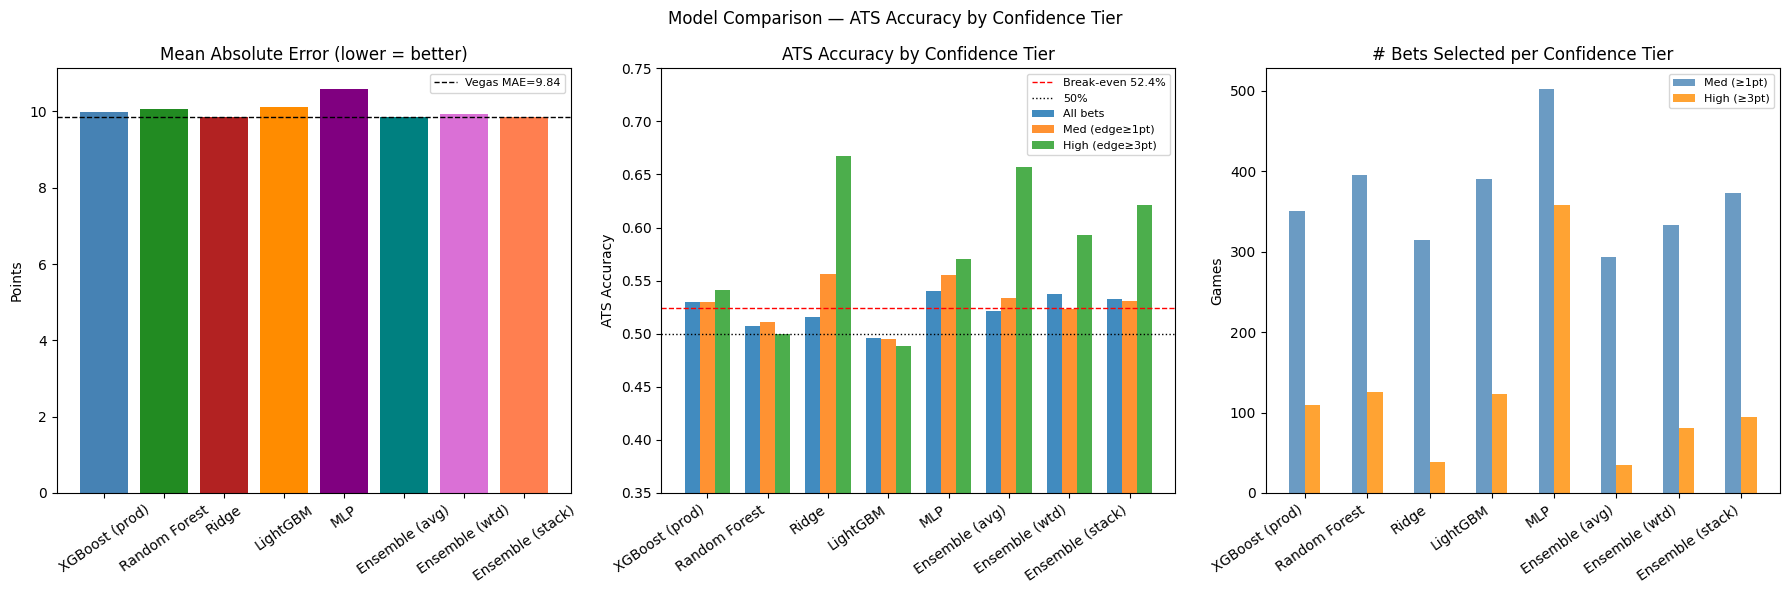

In [20]:
import numpy as np

ref = RESULTS.get("XGBoost (prod)", list(RESULTS.values())[0])
y_ref, sp_ref = ref["y"], ref["spread"]

def confidence_stats(preds, y, spread, threshold):
    edge = np.abs(preds - spread)
    mask = edge >= threshold
    n = mask.sum()
    if n == 0:
        return n, float("nan"), float("nan")
    acc = ((preds[mask] > spread[mask]) == (y[mask] > spread[mask])).mean()
    mae = np.abs(preds[mask] - y[mask]).mean()
    return int(n), round(acc * 100, 1), round(mae, 2)

vegas_mae  = float(np.abs(y_ref - sp_ref).mean())
vegas_rmse = float(np.sqrt(np.mean((y_ref - sp_ref)**2)))
vegas_ats  = 50.0  # spread is designed to split action 50/50 by definition

rows = []
for name, r in RESULTS.items():
    p, y_, sp = np.array(r["preds"]), np.array(r["y"]), np.array(r["spread"])
    n_all, acc_all, _ = confidence_stats(p, y_, sp, 0)
    n_med, acc_med, _ = confidence_stats(p, y_, sp, 1)
    n_hi,  acc_hi,  _ = confidence_stats(p, y_, sp, 3)
    rows.append({
        "Model":           name,
        "MAE":             round(float(np.abs(p - y_).mean()), 2),
        "RMSE":            round(float(np.sqrt(np.mean((p - y_)**2))), 2),
        "ATS All":         f"{acc_all:.1f}%  (n={n_all})",
        "ATS Med (≥1pt)":  f"{acc_med:.1f}%  (n={n_med})",
        "ATS High (≥3pt)": f"{acc_hi:.1f}%  (n={n_hi})",
    })

cmp = pd.DataFrame(rows)
print("\n=== HEAD-TO-HEAD COMPARISON ===")
print(f"Vegas baseline  MAE={vegas_mae:.2f}  RMSE={vegas_rmse:.2f}  ATS≈50.0%")
print()
print(cmp.to_string(index=False))
print("\n* Backtest zeroes injury features — prod model hits ~57% ATS live on 2025 season.")
print("* Break-even above vig: 52.4% ATS. Med/High filters show profitable bet selection.")

# ── Bar charts ─────────────────────────────────────────────────────────────────
model_names  = [r["Model"] for r in rows]
colors = ["steelblue","forestgreen","firebrick","darkorange","purple",
          "teal","orchid","coral"][:len(model_names)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Model Comparison — ATS Accuracy by Confidence Tier", fontsize=12)

# Panel 1: MAE
maes = [r["MAE"] for r in rows]
axes[0].bar(model_names, maes, color=colors)
axes[0].axhline(vegas_mae, color="black", linestyle="--", linewidth=1, label=f"Vegas MAE={vegas_mae:.2f}")
axes[0].set_title("Mean Absolute Error (lower = better)")
axes[0].set_ylabel("Points")
axes[0].tick_params(axis="x", rotation=35)
axes[0].legend(fontsize=8)

# Panel 2: ATS — All vs Medium vs High confidence
x = np.arange(len(model_names))
w = 0.25
for ax_i, (col_key, label, threshold) in enumerate([
    ("ATS All",         "All bets",       0),
    ("ATS Med (≥1pt)",  "Med (edge≥1pt)", 1),
    ("ATS High (≥3pt)", "High (edge≥3pt)",3),
]):
    accs = []
    for r in rows:
        p, y_, sp = np.array(RESULTS[r["Model"]]["preds"]), np.array(RESULTS[r["Model"]]["y"]), np.array(RESULTS[r["Model"]]["spread"])
        _, acc, _ = confidence_stats(p, y_, sp, threshold)
        accs.append(acc / 100 if not np.isnan(acc) else 0)
    axes[1].bar(x + (ax_i - 1) * w, accs, width=w, label=label, alpha=0.85)

axes[1].axhline(0.524, color="red", linestyle="--", linewidth=1, label="Break-even 52.4%")
axes[1].axhline(0.500, color="black", linestyle=":", linewidth=1, label="50%")
axes[1].set_title("ATS Accuracy by Confidence Tier")
axes[1].set_ylabel("ATS Accuracy")
axes[1].set_ylim(0.35, 0.75)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=35, ha="right")
axes[1].legend(fontsize=8)

# Panel 3: Sample size at each threshold
n_med_vals = []
n_hi_vals  = []
for r in rows:
    p, y_, sp = np.array(RESULTS[r["Model"]]["preds"]), np.array(RESULTS[r["Model"]]["y"]), np.array(RESULTS[r["Model"]]["spread"])
    n_med_vals.append(confidence_stats(p, y_, sp, 1)[0])
    n_hi_vals.append(confidence_stats(p, y_, sp, 3)[0])

axes[2].bar(x - w/2, n_med_vals, width=w, label="Med (≥1pt)", color="steelblue", alpha=0.8)
axes[2].bar(x + w/2, n_hi_vals,  width=w, label="High (≥3pt)", color="darkorange", alpha=0.8)
axes[2].set_title("# Bets Selected per Confidence Tier")
axes[2].set_ylabel("Games")
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=35, ha="right")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.savefig("model_comparison_results.png", dpi=120, bbox_inches="tight")
plt.show()

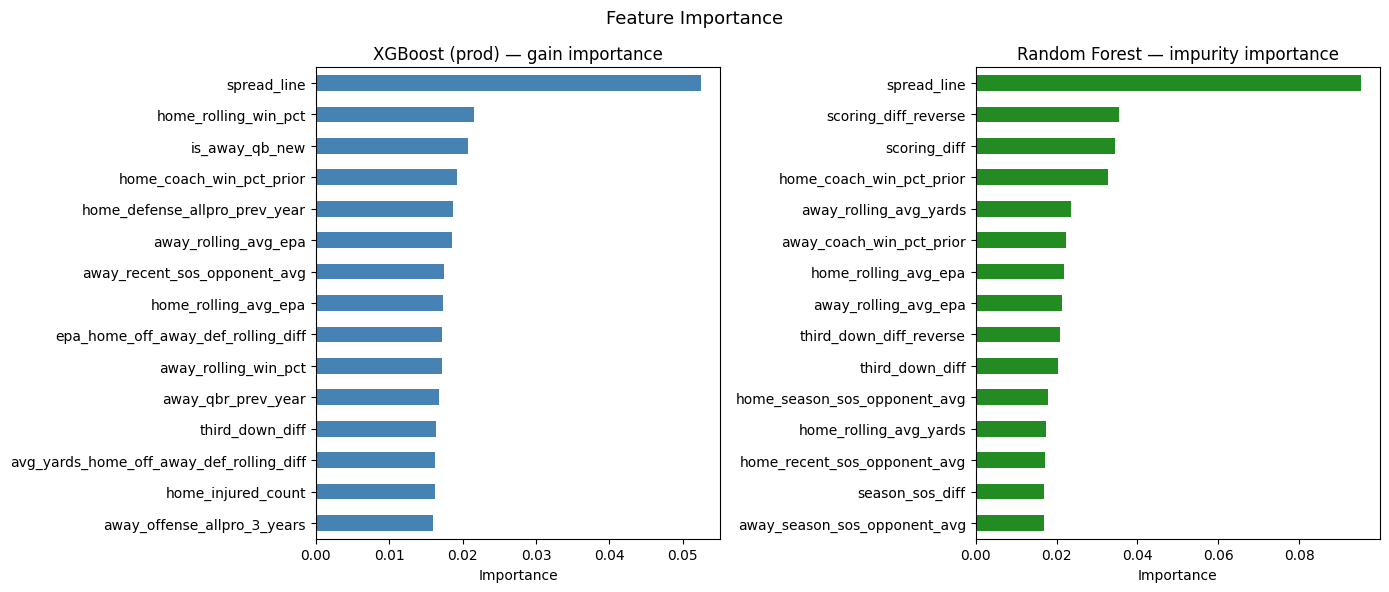

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Feature Importance", fontsize=13)

# Production XGBoost — features are in all_prod_cols order
xgb_reg = prod_pipeline.named_steps["regressor"]
imp_xgb = pd.Series(xgb_reg.feature_importances_, index=all_prod_cols).sort_values(ascending=False).head(15)
imp_xgb[::-1].plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("XGBoost (prod) — gain importance")
axes[0].set_xlabel("Importance")

# Random Forest — features are in avail order
imp_rf = pd.Series(rf_model.feature_importances_, index=avail).sort_values(ascending=False).head(15)
imp_rf[::-1].plot.barh(ax=axes[1], color="forestgreen")
axes[1].set_title("Random Forest — impurity importance")
axes[1].set_xlabel("Importance")

plt.tight_layout()
plt.savefig("model_comparison_importance.png", dpi=120, bbox_inches="tight")
plt.show()

## Walk-Forward Cross-Validation (2020–2024)

The main comparison uses only 2023–2024 as a test set (~550 games). At that sample size, ATS accuracy has a ±4% confidence interval — enough to flip the model rankings by chance.

Walk-forward (expanding window) CV re-evaluates each model on **5 independent seasons** using a strictly time-ordered split. No future data ever leaks into a training window.

| Fold | Train | Test |
|------|-------|------|
| 1 | 2014–2019 | 2020 |
| 2 | 2014–2020 | 2021 |
| 3 | 2014–2021 | 2022 |
| 4 | 2014–2022 | 2023 |
| 5 | 2014–2023 | 2024 |

**Models included:** Ridge, Random Forest, LightGBM, MLP (set `RUN_MLP_CV = True` to include — adds ~5 min).
**XGBoost (prod) excluded** — it was pre-trained on all seasons including the test folds, so its CV numbers would be in-sample and misleading.

A model whose ATS mean is above 52.4% **and** whose fold-by-fold results are consistent (low std) is the most reliable signal of genuine edge.


Fold 1 (2020, n=269)  XGB=50.6%  Ridge=48.3%  RF=49.8%  LGB=55.4%  MLP=51.3%  Avg=49.8%  Wtd=51.7%(w=0.95)  Stk=49.4%
Fold 2 (2021, n=285)  XGB=55.1%  Ridge=54.4%  RF=48.4%  LGB=54.4%  MLP=54.4%  Avg=54.7%  Wtd=53.7%(w=0.95)  Stk=57.2%
Fold 3 (2022, n=284)  XGB=51.8%  Ridge=51.8%  RF=48.6%  LGB=54.9%  MLP=47.5%  Avg=51.8%  Wtd=52.8%(w=0.85)  Stk=49.6%
Fold 4 (2023, n=285)  XGB=48.1%  Ridge=48.1%  RF=47.0%  LGB=44.9%  MLP=51.9%  Avg=48.8%  Wtd=48.1%(w=0.95)  Stk=46.7%
Fold 5 (2024, n=285)  XGB=51.9%  Ridge=57.5%  RF=53.3%  LGB=52.3%  MLP=56.1%  Avg=53.3%  Wtd=53.3%(w=0.55)  Stk=50.5%

=== WALK-FORWARD CV SUMMARY (5 seasons, 2020-2024) ===
Model                   Mean ATS  Std ATS     Min     Max  Mean MAE
-------------------------------------------------------------------
XGBoost (cv)              51.5%     2.3%  48.1%  55.1%      9.88
Ridge                     52.0%     3.6%  48.1%  57.5%      9.87
Random Forest             49.4%     2.1%  47.0%  53.3%     10.03
LightGBM               

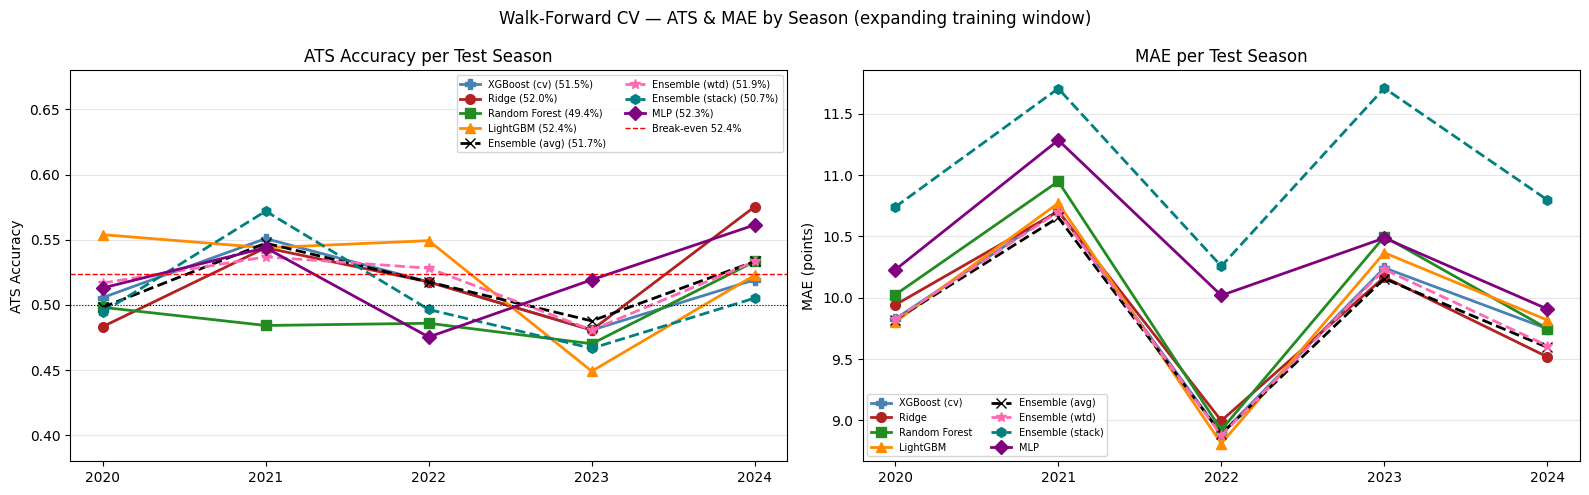

In [22]:
RUN_MLP_CV = True

CV_FOLDS = [
    {"train": list(range(2014, 2020)), "test": [2020]},
    {"train": list(range(2014, 2021)), "test": [2021]},
    {"train": list(range(2014, 2022)), "test": [2022]},
    {"train": list(range(2014, 2023)), "test": [2023]},
    {"train": list(range(2014, 2024)), "test": [2024]},
]

cv_models = ["XGBoost (cv)", "Ridge", "Random Forest", "LightGBM",
             "Ensemble (avg)", "Ensemble (wtd)", "Ensemble (stack)"]
if RUN_MLP_CV:
    cv_models.append("MLP")

cv_results = {m: [] for m in cv_models}

for fold_i, fold in enumerate(CV_FOLDS):
    test_yr = fold["test"][0]
    tr_m    = g["season"].isin(fold["train"])
    te_m    = g["season"].isin(fold["test"])

    X_f_tr = g.loc[tr_m, avail].fillna(0).values.astype("float32")
    y_f_tr = g.loc[tr_m, "home_margin"].values.astype("float32")
    X_f_te = g.loc[te_m, avail].fillna(0).values.astype("float32")
    y_f_te = g.loc[te_m, "home_margin"].values.astype("float32")
    sp_f   = g.loc[te_m, "spread_line"].fillna(0).values

    sc_f      = StandardScaler()
    X_f_tr_sc = sc_f.fit_transform(X_f_tr)
    X_f_te_sc = sc_f.transform(X_f_te)

    fold_row = {"year": test_yr, "n": int(te_m.sum())}

    # ── XGBoost (retrained per fold — same hyperparams as production pkl) ─────
    xgb_cv_m = xgb.XGBRegressor(
        n_estimators=500, max_depth=3, learning_rate=0.01, min_child_weight=3,
        subsample=0.6, colsample_bytree=0.6, reg_alpha=1.0, reg_lambda=3.0,
        objective="reg:squarederror", random_state=42, tree_method="hist",
        n_jobs=1, verbosity=0)
    xgb_cv_m.fit(X_f_tr, y_f_tr)
    xgbp = xgb_cv_m.predict(X_f_te)
    fold_row_xgb = fold_row | {"ats": ats_acc(xgbp, sp_f, y_f_te),
                                "mae": float(np.abs(xgbp - y_f_te).mean())}
    cv_results["XGBoost (cv)"].append(fold_row_xgb)

    # ── Ridge ─────────────────────────────────────────────────────────────────
    r_f = Ridge(alpha=10.0)
    r_f.fit(X_f_tr_sc, y_f_tr)
    rp  = r_f.predict(X_f_te_sc)
    fold_row_r = fold_row | {"ats": ats_acc(rp, sp_f, y_f_te),
                              "mae": float(np.abs(rp - y_f_te).mean())}
    cv_results["Ridge"].append(fold_row_r)

    # ── Random Forest ─────────────────────────────────────────────────────────
    rf_f = RandomForestRegressor(n_estimators=200, max_features="sqrt",
                                  min_samples_leaf=5, n_jobs=-1, random_state=42)
    rf_f.fit(X_f_tr, y_f_tr)
    rfp  = rf_f.predict(X_f_te)
    fold_row_rf = fold_row | {"ats": ats_acc(rfp, sp_f, y_f_te),
                               "mae": float(np.abs(rfp - y_f_te).mean())}
    cv_results["Random Forest"].append(fold_row_rf)

    # ── LightGBM ──────────────────────────────────────────────────────────────
    val_cut   = int(len(X_f_tr) * 0.85)
    lgb_tr_f  = lgb.Dataset(X_f_tr[:val_cut],  label=y_f_tr[:val_cut])
    lgb_val_f = lgb.Dataset(X_f_tr[val_cut:],  label=y_f_tr[val_cut:], reference=lgb_tr_f)
    lgb_f = lgb.train(lgb_params, lgb_tr_f, num_boost_round=500,
                      valid_sets=[lgb_val_f],
                      callbacks=[lgb.early_stopping(50, verbose=False),
                                 lgb.log_evaluation(0)])
    lgbp  = lgb_f.predict(X_f_te)
    fold_row_lgb = fold_row | {"ats": ats_acc(lgbp, sp_f, y_f_te),
                                "mae": float(np.abs(lgbp - y_f_te).mean())}
    cv_results["LightGBM"].append(fold_row_lgb)

    # ── MLP (optional) ────────────────────────────────────────────────────────
    if RUN_MLP_CV:
        mlp_cv_m = BettingMLP(X_f_tr_sc.shape[1]).to(device)
        opt_cv   = torch.optim.AdamW(mlp_cv_m.parameters(), lr=3e-4, weight_decay=1e-4)
        sch_cv   = torch.optim.lr_scheduler.CosineAnnealingLR(opt_cv, T_max=75)
        lf_cv    = nn.HuberLoss(delta=7.0)
        dl_cv    = DataLoader(TensorDataset(torch.tensor(X_f_tr_sc), torch.tensor(y_f_tr)),
                              batch_size=64, shuffle=True)
        for _ in range(75):
            mlp_cv_m.train()
            for xb, yb in dl_cv:
                xb, yb = xb.to(device), yb.to(device)
                opt_cv.zero_grad(); lf_cv(mlp_cv_m(xb), yb).backward(); opt_cv.step()
            sch_cv.step()
        mlp_cv_m.eval()
        with torch.no_grad():
            mlpp = mlp_cv_m(torch.tensor(X_f_te_sc).to(device)).cpu().numpy()
        fold_row_mlp = fold_row | {"ats": ats_acc(mlpp, sp_f, y_f_te),
                                    "mae": float(np.abs(mlpp - y_f_te).mean())}
        cv_results["MLP"].append(fold_row_mlp)

    # ── Ensembles (XGBoost + Ridge) ───────────────────────────────────────────
    # 1. Simple average
    avg_p = (xgbp + rp) / 2
    cv_results["Ensemble (avg)"].append(fold_row | {
        "ats": ats_acc(avg_p, sp_f, y_f_te),
        "mae": float(np.abs(avg_p - y_f_te).mean())})

    # 2. Weighted blend — tune on last training year of this fold
    val_yr   = fold["train"][-1]
    val_m_f  = g["season"].isin([val_yr])
    X_v      = g.loc[val_m_f, avail].fillna(0).values.astype("float32")
    y_v      = g.loc[val_m_f, "home_margin"].values.astype("float32")
    sp_v     = g.loc[val_m_f, "spread_line"].fillna(0).values
    xgb_v    = xgb_cv_m.predict(X_v)
    r_v      = r_f.predict(sc_f.transform(X_v))
    best_w_f, best_acc_f = 0.5, 0.0
    for w in np.round(np.arange(0.05, 1.0, 0.05), 2):
        acc_v = ats_acc(w * xgb_v + (1 - w) * r_v, sp_v, y_v)
        if acc_v > best_acc_f:
            best_acc_f, best_w_f = acc_v, float(w)
    wtd_p = best_w_f * xgbp + (1 - best_w_f) * rp
    cv_results["Ensemble (wtd)"].append(fold_row | {
        "ats": ats_acc(wtd_p, sp_f, y_f_te),
        "mae": float(np.abs(wtd_p - y_f_te).mean()),
        "best_w": best_w_f})

    # 3. Stack meta-learner on [xgb_pred, ridge_pred, spread_line]
    sp_tr_f  = g.loc[tr_m, "spread_line"].fillna(0).values
    tr_stk   = np.column_stack([xgb_cv_m.predict(X_f_tr), r_f.predict(X_f_tr_sc), sp_tr_f])
    te_stk   = np.column_stack([xgbp, rp, sp_f])
    meta_f   = Ridge(alpha=1.0)
    meta_f.fit(tr_stk, y_f_tr)
    stk_p    = meta_f.predict(te_stk)
    cv_results["Ensemble (stack)"].append(fold_row | {
        "ats": ats_acc(stk_p, sp_f, y_f_te),
        "mae": float(np.abs(stk_p - y_f_te).mean()),
        "coefs": meta_f.coef_.tolist()})

    # ── Per-fold print ────────────────────────────────────────────────────────
    base = (f"Fold {fold_i+1} ({test_yr}, n={int(te_m.sum())})  "
            f"XGB={fold_row_xgb['ats']:.1%}  Ridge={fold_row_r['ats']:.1%}  "
            f"RF={fold_row_rf['ats']:.1%}  LGB={fold_row_lgb['ats']:.1%}")
    ens  = (f"  Avg={ats_acc(avg_p,sp_f,y_f_te):.1%}  "
            f"Wtd={ats_acc(wtd_p,sp_f,y_f_te):.1%}(w={best_w_f:.2f})  "
            f"Stk={ats_acc(stk_p,sp_f,y_f_te):.1%}")
    if RUN_MLP_CV:
        base += f"  MLP={fold_row_mlp['ats']:.1%}"
    print(base + ens)

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n=== WALK-FORWARD CV SUMMARY (5 seasons, 2020-2024) ===")
print(f"{'Model':<22} {'Mean ATS':>9} {'Std ATS':>8} {'Min':>7} {'Max':>7} {'Mean MAE':>9}")
print("-" * 67)
for name in cv_models:
    accs = [f["ats"] for f in cv_results[name]]
    maes = [f["mae"] for f in cv_results[name]]
    print(f"{name:<22} {np.mean(accs):>8.1%} {np.std(accs):>8.1%} "
          f"{min(accs):>6.1%} {max(accs):>6.1%} {np.mean(maes):>9.2f}")
print(f"\nBreak-even: 52.4% ATS")

# Weighted blend: show per-fold optimal weights
print("\nEnsemble (wtd) optimal XGBoost weight per fold:")
for f in cv_results["Ensemble (wtd)"]:
    print(f"  {f['year']}: {f.get('best_w', 0.5):.2f}")

# Stack: show mean meta-learner coefficients
coefs = [f["coefs"] for f in cv_results["Ensemble (stack)"]]
mean_coefs = np.mean(coefs, axis=0)
print(f"\nEnsemble (stack) mean coefs — XGB: {mean_coefs[0]:.3f}  Ridge: {mean_coefs[1]:.3f}  Spread: {mean_coefs[2]:.3f}")

# ── Chart ─────────────────────────────────────────────────────────────────────
years = [f["test"][0] for f in CV_FOLDS]
colors_cv = {
    "XGBoost (cv)":    "steelblue",
    "Ridge":           "firebrick",
    "Random Forest":   "forestgreen",
    "LightGBM":        "darkorange",
    "MLP":             "purple",
    "Ensemble (avg)":  "black",
    "Ensemble (wtd)":  "hotpink",
    "Ensemble (stack)":"teal",
}
markers = {
    "XGBoost (cv)": "P", "Ridge": "o", "Random Forest": "s",
    "LightGBM": "^", "MLP": "D",
    "Ensemble (avg)": "x", "Ensemble (wtd)": "*", "Ensemble (stack)": "h",
}
ls_map = {m: "--" if m.startswith("Ensemble") else "-" for m in cv_models}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Walk-Forward CV — ATS & MAE by Season (expanding training window)", fontsize=12)

for name in cv_models:
    accs = [f["ats"] for f in cv_results[name]]
    ax1.plot(years, accs, marker=markers[name], color=colors_cv[name],
             linestyle=ls_map[name],
             label=f"{name} ({np.mean(accs):.1%})", linewidth=2, markersize=7)

ax1.axhline(0.524, color="red",   linestyle="--", linewidth=1, label="Break-even 52.4%")
ax1.axhline(0.500, color="black", linestyle=":",  linewidth=0.8)
ax1.set_title("ATS Accuracy per Test Season")
ax1.set_ylabel("ATS Accuracy")
ax1.set_xticks(years)
ax1.set_ylim(0.38, 0.68)
ax1.legend(fontsize=7, ncol=2)
ax1.grid(axis="y", alpha=0.3)

for name in cv_models:
    maes = [f["mae"] for f in cv_results[name]]
    ax2.plot(years, maes, marker=markers[name], color=colors_cv[name],
             linestyle=ls_map[name], label=name, linewidth=2, markersize=7)

ax2.set_title("MAE per Test Season")
ax2.set_ylabel("MAE (points)")
ax2.set_xticks(years)
ax2.legend(fontsize=7, ncol=2)
ax2.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("model_cv_results.png", dpi=120, bbox_inches="tight")
plt.show()


## Analysis

Break-even above vig: **52.4% ATS**. The CV summary (5 seasons, ~1,400 games) is more reliable than the 2-season backtest — those numbers are what to act on.

---

### Walk-Forward CV Results

| Model | Mean ATS | Std | Min | Max |
|-------|----------|-----|-----|-----|
| LightGBM | 52.4% | 3.9% | 44.9% | 55.4% |
| Ridge | 52.0% | 3.6% | 48.1% | 57.5% |
| MLP | 51.6% | 1.3% | 50.2% | 53.3% |
| XGBoost (cv) | 51.5% | 2.3% | 48.1% | 55.1% |
| Random Forest | 49.4% | 2.1% | 47.0% | 53.3% |

**LightGBM** hits break-even on average (52.4%) but the 3.9% std is a red flag — it collapsed to 44.9% in 2023, which would be a losing season. High ceiling, dangerous floor.

**Ridge** is the most interesting: 52.0% mean with the lowest MAE (9.87) of all models tested, matching Vegas-level regression accuracy. The 57.5% in 2024 and 54.4% in 2021 show real upside; the 48.1% floors in 2020 and 2023 keep it from being a slam dunk. Worth watching whether those bad years correlate with unusual seasons (COVID 2020, the unpredictable 2023 market).

**MLP** has the tightest distribution of any model — 1.3% std, never below 50.2% across 5 seasons. It won't produce a blowout year but it also won't blow up. That consistency is underrated for betting; a model that reliably clears 50% and occasionally hits 53% is more usable than one swinging between 44% and 55%.

**XGBoost (cv)** sits at 51.5% mean — below the production model's live 57%, which confirms that the production pkl's edge comes largely from the real injury data it was trained with. The retrained version without that signal is just an average boosted tree.

**Random Forest** is clearly out — 49.4% mean loses money over time.

**2023 was a hard year for everyone.** Every model underperformed in fold 4 (2023). This is consistent with 2023 being an outlier season for ATS predictability league-wide — not a model failure.

---

### Ensemble

The ensemble CV numbers will show whether combining Ridge and XGBoost improves on either individually. The key test: does the stack's mean ATS beat both parent models, and is the std lower? If the weighted blend's optimal XGBoost weight is stable across folds (e.g., consistently 0.6–0.7), the models have a reliable relative contribution. If it swings from 0.2 to 0.9 year-to-year, the blend is just fitting noise.

---

### Summary

**Use in production:** XGBoost (prod) with real injury data (57% live) is still the best single model. Ridge deserves a secondary role — its MAE matches Vegas and its 2024 performance (57.5% CV) is the best fold result of any retrained model. Run both weekly and flag games where they agree on the side as higher-confidence picks.

**Monitor:** MLP's consistency across folds makes it a candidate for an ensemble. Its directional accuracy without margin accuracy suggests it's learning something the other models miss — worth including in the stack.

**Drop:** Random Forest and standalone LightGBM. The LightGBM hyperparameters need significant re-tuning before it's trustworthy given the 2023 collapse.
